**E-COMMERCE FUNNEL ANALYSIS**

**Contributor**

Gordon Moenga

**1. OVERVIEW**

The online retailer seeks to improve its sales performance by gaining a deeper understanding of customer behavior throughout the purchasing journey. This project analyzes e-commerce funnel data to evaluate how users progress from the homepage to checkout, with a focus on identifying conversion patterns and points of abandonment. The analysis examines customer behavior across different user types (New and Returning), traffic channels (Organic, Paid and Referral), and product categories. By identifying the stages with the highest drop-off rates and comparing conversion performance across key customer segments, the project provides actionable insights to help stakeholders optimize the user experience, improve marketing effectiveness, and increase overall conversion rates.

**Methodology:** A structured workflow was followed, covering data preparation, exploratory analysis, funnel analysis and dashboard development.

**Data Preparation:** The dataset was validated and prepared by resolving missing values, removing duplicates, correcting data types and standardizing categorical variables to ensure data quality and analytical accuracy.

**Exploratory Data Analysis:** Customer behaviour, user segments and traffic sources were explored using descriptive statistics and visualisations to understand user distribution and engagement throughout the purchasing funnel.

**Funnel Analysis:** Conversion rates were calculated at each stage of the customer journey (Home → Category → Product → Add to Cart → Checkout). Performance was then compared across user types, traffic channels and product categories to identify conversion patterns, quantify customer drop-offs and uncover opportunities to improve the purchasing experience.

**Dashboard Development:** An interactive Power BI dashboard was developed to present key performance indicators, funnel conversion metrics, segment comparisons and customer drop-off patterns, enabling stakeholders to monitor funnel performance and support data-driven decision-making.

**2. BUSINESS UNDERSTANDING**

In e-commerce, converting website visitors into paying customers is essential for driving revenue and business growth. This analysis evaluates how users progress through the purchasing funnel by measuring conversion rates between each stage of the customer journey and identifying where the largest drop-offs occur. By comparing funnel performance across user types, traffic channels and product categories, the project provides insights that help stakeholders optimize the customer experience, improve marketing effectiveness and increase overall conversion rates.

**2.1 Key Business Questions**

**Funnel Performance:** How effectively does the e-commerce funnel convert users from the homepage to checkout?

**Customer Behaviour:** At which stage of the purchasing journey are the largest customer drop-offs occurring?

**User Performance:** How do conversion rates differ between new and returning users?

**Traffic Channel Performance:** Which traffic channels generate the highest-quality traffic based on conversion performance?

**Product Category Performance:** Which product categories achieve the highest and lowest conversion rates?

**2.2 Analysis Goals**

The primary goals of this project are to:

- Measure conversion rates at each stage of the e-commerce purchasing funnel.
- Identify the stages where the largest customer drop-offs occur.
- Compare conversion performance across user types, traffic channels and product categories.
- Uncover patterns in customer behaviour that influence purchase completion.
- Provide actionable recommendations to optimize the customer journey and improve overall conversion rates.

**3. DATA UNDERSTANDING**

The dataset contains customer interaction data captured across the e-commerce purchasing funnel. It includes information on user progression through each funnel stage (Home, Category, Product, Add to Cart and Checkout), along with user type (New and Returning), traffic channel (Organic, Paid and Referral) and product category.

**4. DATA PREPARATION**

**4.1 Data Loading**

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
# loading the dataset to be analysed
ecommerce_data = pd.read_csv("ecommerce_funnel_case_complex.csv")

**4.2 Detailed Data Cleaning**

In [4]:
# display the first five records
ecommerce_data.head()

,session_id,user_type,channel,product,page,event_time,purchase_flag
0,1,New,Referral,Watch,Home,2025-10-20 16:16:00,0
1,2,Returning,Paid,Bag,Home,2025-10-20 16:21:00,0
2,2,Returning,Paid,Bag,Category,2025-10-20 16:23:38,0
3,2,Returning,Paid,Bag,Product,2025-10-20 16:33:37,0
4,3,New,Organic,Jacket,Home,2025-10-21 04:41:00,0


In [5]:
# display the last five records
ecommerce_data.tail()

,session_id,user_type,channel,product,page,event_time,purchase_flag
2985,998,New,Paid,Jacket,Product,2025-10-20 19:56:44,0
2986,998,New,Paid,Jacket,AddToCart,2025-10-20 20:05:51,0
2987,999,New,Paid,Watch,Home,2025-10-20 09:10:00,0
2988,999,New,Paid,Watch,Category,2025-10-20 09:17:05,0
2989,1000,Returning,Organic,Jacket,Home,2025-10-20 22:31:00,0


In [6]:
# number of rows and columns
ecommerce_data.shape

(2990, 7)

In [7]:
# statistical summary of the dataset
ecommerce_data.describe(include="all")

,session_id,user_type,channel,product,page,event_time,purchase_flag
count,2990.000000,2990,2990,2990,2990,2990,2990.000000
unique,NaN,2,3,4,5,2666,NaN
top,NaN,New,Organic,Jacket,Home,2025-10-21 03:56:00,NaN
freq,NaN,2022,1495,793,1000,5,NaN
mean,500.024749,NaN,NaN,NaN,NaN,NaN,0.024749
std,289.870203,NaN,NaN,NaN,NaN,NaN,0.155386
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,255.250000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,496.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,755.000000,NaN,NaN,NaN,NaN,NaN,0.000000


In [8]:
# dataset information
ecommerce_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2990 entries, 0 to 2989
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   session_id     2990 non-null   int64 
 1   user_type      2990 non-null   object
 2   channel        2990 non-null   object
 3   product        2990 non-null   object
 4   page           2990 non-null   object
 5   event_time     2990 non-null   object
 6   purchase_flag  2990 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 163.6+ KB


In [9]:
# check for missing values
ecommerce_data.isnull().sum()

session_id       0
user_type        0
channel          0
product          0
page             0
event_time       0
purchase_flag    0
dtype: int64

In [10]:
# identify datatypes
ecommerce_data.dtypes

session_id        int64
user_type        object
channel          object
product          object
page             object
event_time       object
purchase_flag     int64
dtype: object

In [11]:
# check for duplicate records
ecommerce_data.duplicated().sum()

np.int64(0)

In [19]:
# checking for unique values
ecommerce_data.nunique()

session_id       1000
user_type           2
channel             3
product             4
page                5
event_time       2666
purchase_flag       2
dtype: int64

In [31]:
# checking for inconsistencies in categorical columns
sorted(ecommerce_data["page"].unique())

['AddToCart', 'Category', 'Checkout', 'Home', 'Product']

In [32]:
sorted(ecommerce_data["channel"].unique())

['Organic', 'Paid', 'Referral']

In [33]:
sorted(ecommerce_data["user_type"].unique())

['New', 'Returning']

In [34]:
sorted(ecommerce_data["product"].unique())

['Bag', 'Jacket', 'Shoes', 'Watch']

**5. DATA ANALYSIS AND VISUALIZATION**

**5.1 Funnel Conversion Analysis**

In [14]:
# Count unique sessions at each funnel stage
funnel_counts = (
    ecommerce_data.groupby("page")["session_id"]
    .nunique()
    .reindex(["Home","Category", "Product", "AddToCart", "Checkout"])
)

funnel_counts

page
Home         1000
Category      848
Product       603
AddToCart     365
Checkout      174
Name: session_id, dtype: int64

In [15]:
# create a funnel summary table
funnel_summary = funnel_counts.to_frame(name="Sessions")
funnel_summary

,Sessions
page,
Home,1000
Category,848
Product,603
AddToCart,365
Checkout,174


In [17]:
# calculate conversion rate between consecutive funnel stages
funnel_summary["Conversion Rate (%)"] = (
    (funnel_summary["Sessions"] /
    funnel_summary["Sessions"].shift(1) * 100)
    .round(2)
)

funnel_summary.iloc[0, 1] = 100
funnel_summary

,Sessions,Conversion Rate (%)
page,,
Home,1000,100.00
Category,848,84.80
Product,603,71.11
AddToCart,365,60.53
Checkout,174,47.67


In [18]:
# calculate the overall conversion rate
overall_conversion = (
    funnel_summary.loc["Checkout", "Sessions"] / 
    funnel_summary.loc["Home", "Sessions"]) * 100

print(f"Overall Funnel Conversion Rate: {overall_conversion:.2f}%")

Overall Funnel Conversion Rate: 17.40%


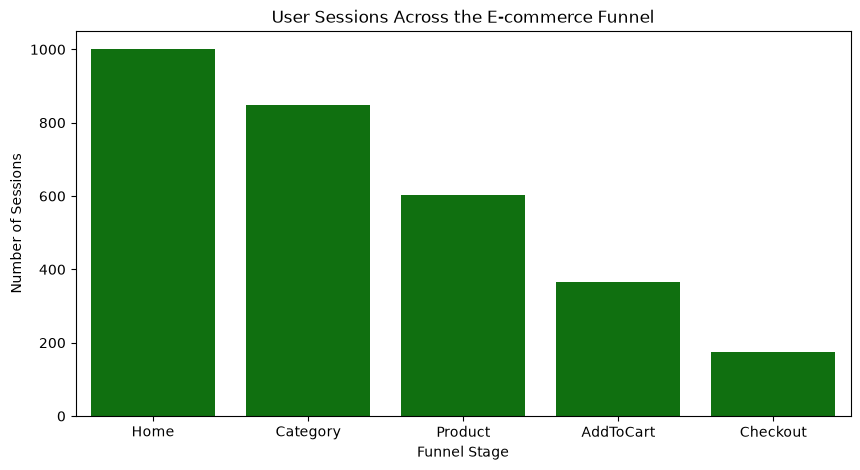

In [19]:
# visualise user sessions across the funnel
plt.figure(figsize=(10,5))
sns.barplot(x=funnel_summary.index, y=funnel_summary.Sessions, color="green")
plt.title("User Sessions Across the E-commerce Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.show()

#### Insight:

Customer sessions decline steadily across the purchasing funnel, from 1,000 sessions at the Home page to 174 sessions at Checkout. The largest reduction occurs between the Product and Add to Cart stages, indicating a key point of customer abandonment. Overall, the funnel achieves a 17.4% conversion rate, highlighting opportunities to improve the customer journey and increase purchase completion.

**5.2 User Type Analysis**

In [20]:
# count unique sessions by user type and funnel stage
user_type_counts = (
    ecommerce_data.groupby(["user_type", "page"])["session_id"]
        .nunique()
        .unstack()
        .reindex(columns=["Home","Category", "Product", "AddToCart", "Checkout"])
)

user_type_counts

page,Home,Category,Product,AddToCart,Checkout
user_type,,,,,
New,675,572,407,251,117
Returning,325,276,196,114,57


In [21]:
# calculate conversion rates
user_conversion = (
    (user_type_counts
    .div(user_type_counts.Home, axis=0) * 100)
    .round(2)
)

user_conversion

page,Home,Category,Product,AddToCart,Checkout
user_type,,,,,
New,100.0,84.74,60.30,37.19,17.33
Returning,100.0,84.92,60.31,35.08,17.54


<Figure size 1000x500 with 0 Axes>

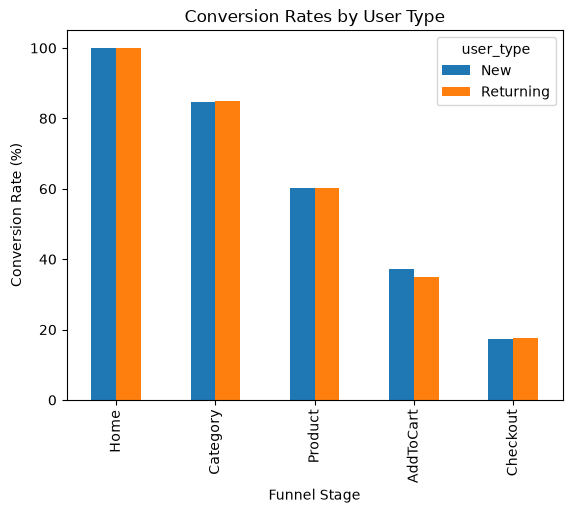

In [32]:
# Visualise conversion rates by user type
plt.figure(figsize=(10,5))
user_conversion.T.plot(kind="bar")
plt.title("Conversion Rates by User Type")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")
plt.show()

The DataFrame is transposed (.T) so that the funnel stages appear on the x-axis while New and Returning users are displayed as separate bars within each stage.

#### Insight:

New and Returning users exhibit nearly identical conversion patterns throughout the purchasing funnel. While Returning users achieve a slightly higher overall conversion rate of 17.54%  than New users with 17.33%, the difference is minimal, suggesting that user type has little influence on conversion performance.


**5.3 Traffic Channel Analysis**

In [23]:
# count unique sessions by traffic channel and funnel stage
channel_counts = (
    ecommerce_data.groupby(["channel", "page"])["session_id"]
        .nunique()
        .unstack()
        .reindex(columns=["Home", "Category", "Product", "AddToCart", "Checkout"])
)

channel_counts

page,Home,Category,Product,AddToCart,Checkout
channel,,,,,
Organic,500,424,304,185,82
Paid,306,256,178,106,57
Referral,194,168,121,74,35


In [24]:
# calculate the conversion rates
channel_conversion = (
    (channel_counts.div(channel_counts.Home, axis=0) * 100)
    .round(2)
)

channel_conversion

page,Home,Category,Product,AddToCart,Checkout
channel,,,,,
Organic,100.0,84.80,60.80,37.00,16.40
Paid,100.0,83.66,58.17,34.64,18.63
Referral,100.0,86.60,62.37,38.14,18.04


<Figure size 1200x500 with 0 Axes>

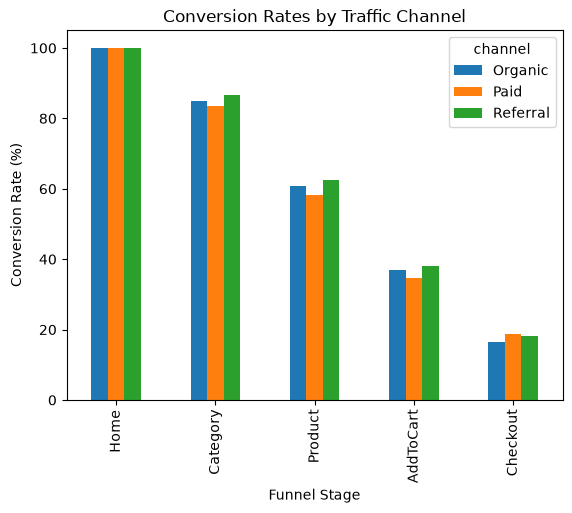

In [33]:
# visualising conversion rate by traffic channel
plt.figure(figsize=(12,5))
channel_conversion.T.plot(kind="bar")
plt.title("Conversion Rates by Traffic Channel")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")
plt.show()

#### Insight:

Referral traffic demonstrates the strongest progression through most stages of the purchasing funnel, achieving the highest conversion rates from Category to Add to Cart. However, Paid traffic records the highest overall checkout conversion rate of 18.63%, while Organic traffic shows the lowest overall conversion of 16.40%, indicating potential opportunities to improve its purchase completion rate.

**5.4 Product Category Analysis**

In [34]:
# count unique sessions by product and funnel stage
product_counts = (
    ecommerce_data.groupby(["product", "page"])["session_id"]
    .nunique()
    .unstack()
    .reindex(columns=["Home", "Category", "Product", "AddToCart", "Checkout"])
)

product_counts

page,Home,Category,Product,AddToCart,Checkout
product,,,,,
Bag,239,203,145,94,52
Jacket,259,224,164,99,47
Shoes,257,217,152,81,40
Watch,245,204,142,91,35


In [29]:
# calculate conversion rate by product
product_conversion = (product_counts.div(product_counts.Home, axis=0) * 100).round(2)
product_conversion

page,Home,Category,Product,AddToCart,Checkout
product,,,,,
Bag,100.0,84.94,60.67,39.33,21.76
Jacket,100.0,86.49,63.32,38.22,18.15
Shoes,100.0,84.44,59.14,31.52,15.56
Watch,100.0,83.27,57.96,37.14,14.29


<Figure size 1600x500 with 0 Axes>

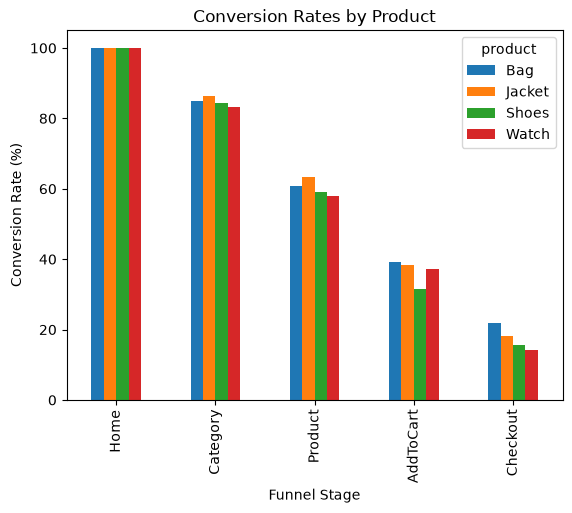

In [35]:
# visualising conversion rate by product
plt.figure(figsize=(16,5))
product_conversion.T.plot(kind="bar")
plt.title("Conversion Rates by Product")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Funnel Stage")
plt.show()

#### Insight:

The Bag category records the highest overall checkout conversion rate of 21.76%, followed by Jacket with 18.15%. In contrast, Shoes and Watch categories exhibit lower conversion rates, suggesting opportunities to improve customer engagement and purchase completion for these product categories.

**5.5 Customer Drop-off Analysis**

In [36]:
# identify the no of sessions lost between funnel stages
drop_off = funnel_summary.Sessions.diff(-1).abs()
drop_off

page
Home         152.0
Category     245.0
Product      238.0
AddToCart    191.0
Checkout       NaN
Name: Sessions, dtype: float64

In [46]:
# create a drop-off summary table
dropoff_summary = pd.DataFrame({'Sessions': funnel_summary.Sessions, 'Sessions_Lost': drop_off})
dropoff_summary

,Sessions,Sessions_Lost
page,,
Home,1000,152.0
Category,848,245.0
Product,603,238.0
AddToCart,365,191.0
Checkout,174,NaN


In [47]:
# calculate the drop-off percentage
dropoff_summary['Dropoff_Rate'] = (
    ((dropoff_summary.Sessions_Lost / dropoff_summary.Sessions) * 100)
        .round(2)
)

dropoff_summary

,Sessions,Sessions_Lost,Dropoff_Rate
page,,,
Home,1000,152.0,15.20
Category,848,245.0,28.89
Product,603,238.0,39.47
AddToCart,365,191.0,52.33
Checkout,174,NaN,NaN


In [48]:
# identify the largest drop-off stage and rate
largest_dropoff = dropoff_summary.Dropoff_Rate[:-1].idxmax()
largest_rate = dropoff_summary.Dropoff_Rate[:-1].max()

print(f"Largest drop-off occurs after {largest_dropoff} stage with a rate of {largest_rate}%")

Largest drop-off occurs after AddToCart stage with a rate of 52.33%


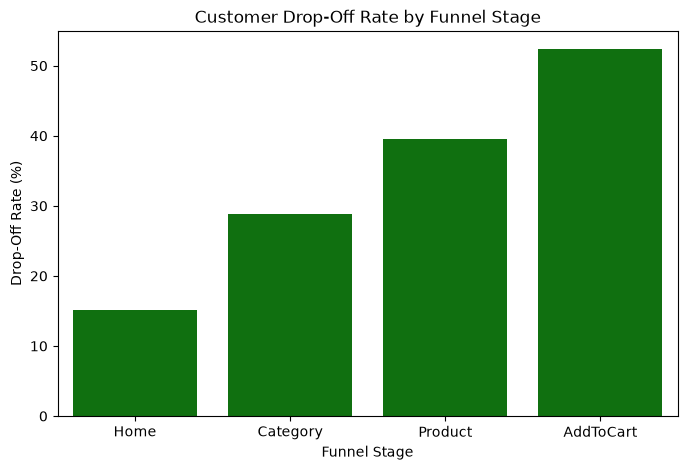

In [49]:
# visualising the drop-off rates
plt.figure(figsize=(8,5))
sns.barplot(x=dropoff_summary.index[:-1], y=dropoff_summary.Dropoff_Rate[:-1], color='green')
plt.title("Customer Drop-Off Rate by Funnel Stage")
plt.ylabel("Drop-Off Rate (%)")
plt.xlabel("Funnel Stage")
plt.show()

#### Insight:

Customer drop-offs increase progressively as users advance through the purchasing funnel. The largest abandonment occurs at the Add to Cart stage, where 52.33% of sessions fail to proceed to checkout. This suggests that the transition from Add to Cart to Checkout is the primary bottleneck in the customer journey and should be prioritized for optimization.

**RECOMMENDATIONS**

1. Optimize the checkout process to reduce the high customer abandonment rate between the Add to Cart and Checkout stages.

2. Improve the Watch and Shoes product categories by enhancing their product pages, pricing strategies, and promotional efforts to increase conversions.

3. Allocate more marketing resources to Referral and Paid channels, as they demonstrated stronger conversion performance than Organic traffic.

4. Enhance product pages to encourage more users to progress from the Product stage to Add to Cart.

5. Continuously monitor funnel conversion metrics to identify emerging bottlenecks and support ongoing data-driven improvements.

**CONCLUSION**

This project analysed the performance of an e-commerce purchasing funnel by evaluating user progression from the Home page to Checkout. The analysis revealed an overall funnel conversion rate of 17.40%, with customer sessions declining steadily at each stage. While conversion performance was broadly consistent across user types, differences were observed across traffic channels and product categories, providing valuable insights into customer behaviour.

The findings highlight opportunities to improve the customer journey, particularly by reducing abandonment between the Add to Cart and Checkout stages, strengthening lower-performing product categories, and leveraging high-performing marketing channels. By implementing these recommendations and continuously monitoring funnel performance, the business can enhance the customer experience, improve conversion rates, and drive sustainable sales growth.